In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For machine learning tasks
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

# Read the dataset (replace with actual file path if using CSV/Excel)
# Assuming dataset has been con"/content/estonia-passenger-list.csvverted to CSV from the DOCX description
df = pd.read_csv(r"https://raw.githubusercontent.com/ek-chris/Practice_datasets/refs/heads/main/EasyVisa%20(1).csv")  # You need to convert the .docx table to CSV first

In [2]:
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [3]:
df.isna().sum()

,0
case_id,0
continent,0
education_of_employee,0
has_job_experience,0
requires_job_training,0
no_of_employees,0
yr_of_estab,0
region_of_employment,0
prevailing_wage,0
unit_of_wage,0


In [4]:
df.shape

(25480, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
print("\nSummary statistics for numeric columns:")
print(df.describe())



Summary statistics for numeric columns:
       no_of_employees   yr_of_estab  prevailing_wage
count     25480.000000  25480.000000     25480.000000
mean       5667.043210   1979.409929     74455.814592
std       22877.928848     42.366929     52815.942327
min         -26.000000   1800.000000         2.136700
25%        1022.000000   1976.000000     34015.480000
50%        2109.000000   1997.000000     70308.210000
75%        3504.000000   2005.000000    107735.512500
max      602069.000000   2016.000000    319210.270000


In [8]:
print("\nUnique values per column:")
print(df.nunique())



Unique values per column:
case_id                  25480
continent                    6
education_of_employee        4
has_job_experience           2
requires_job_training        2
no_of_employees           7105
yr_of_estab                199
region_of_employment         5
prevailing_wage          25454
unit_of_wage                 4
full_time_position           2
case_status                  2
dtype: int64


In [9]:
# --- INSPECT text columns ---
text_cols = df.select_dtypes(include='object').columns
print("\n Unique value samples before standardizing text columns:")
for col in text_cols:
    print(f"\n{col} unique values:\n", df[col].dropna().unique())


 Unique value samples before standardizing text columns:

case_id unique values:
 ['EZYV01' 'EZYV02' 'EZYV03' ... 'EZYV25478' 'EZYV25479' 'EZYV25480']

continent unique values:
 ['Asia' 'Africa' 'North America' 'Europe' 'South America' 'Oceania']

education_of_employee unique values:
 ['High School' "Master's" "Bachelor's" 'Doctorate']

has_job_experience unique values:
 ['N' 'Y']

requires_job_training unique values:
 ['N' 'Y']

region_of_employment unique values:
 ['West' 'Northeast' 'South' 'Midwest' 'Island']

unit_of_wage unique values:
 ['Hour' 'Year' 'Week' 'Month']

full_time_position unique values:
 ['Y' 'N']

case_status unique values:
 ['Denied' 'Certified']


In [10]:
df.columns = df.columns.str.replace('_', ' ').str.title().str.replace(' ', '_')

In [11]:
df.columns

Index(['Case_Id', 'Continent', 'Education_Of_Employee', 'Has_Job_Experience',
       'Requires_Job_Training', 'No_Of_Employees', 'Yr_Of_Estab',
       'Region_Of_Employment', 'Prevailing_Wage', 'Unit_Of_Wage',
       'Full_Time_Position', 'Case_Status'],
      dtype='object')

In [12]:
# --- INSPECT numeric conversion issues ---
print("\n Non-numeric values in numeric fields:")
for col in ['Yr_Of_Estab', 'No_Of_Employees', 'Prevailing_Wage']:
    non_numeric = pd.to_numeric(df[col], errors='coerce').isna() & df[col].notna()
    if non_numeric.any():
        print(f"{col} contains non-numeric entries:\n", df.loc[non_numeric, col].unique())



 Non-numeric values in numeric fields:


In [13]:
# ---INSPECT wage unit variety ---
print("\nUnique Unit_Of_Wage values:\n", df['Unit_Of_Wage'].dropna().unique())


Unique Unit_Of_Wage values:
 ['Hour' 'Year' 'Week' 'Month']


In [14]:
# ---INSPECT missing key fields ---
print("\n Missing values in key fields:")
print(df[['Case_Id', 'Continent', 'Education_Of_Employee', 'Has_Job_Experience',
       'Requires_Job_Training', 'No_Of_Employees', 'Yr_Of_Estab',
       'Region_Of_Employment', 'Prevailing_Wage', 'Unit_Of_Wage',
       'Full_Time_Position', 'Case_Status']].isna().sum())


 Missing values in key fields:
Case_Id                  0
Continent                0
Education_Of_Employee    0
Has_Job_Experience       0
Requires_Job_Training    0
No_Of_Employees          0
Yr_Of_Estab              0
Region_Of_Employment     0
Prevailing_Wage          0
Unit_Of_Wage             0
Full_Time_Position       0
Case_Status              0
dtype: int64


In [15]:
df['Prevailing_Wage'] = df['Prevailing_Wage'].round(2)


In [16]:
df

,Case_Id,Continent,Education_Of_Employee,Has_Job_Experience,Requires_Job_Training,No_Of_Employees,Yr_Of_Estab,Region_Of_Employment,Prevailing_Wage,Unit_Of_Wage,Full_Time_Position,Case_Status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.20,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.65,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.86,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.03,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.39,Year,Y,Certified
...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.57,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.79,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.85,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.77,Year,Y,Certified


In [17]:
# ---INSPECT for unrealistic values ---
print("\n Yr_Of_Estab range:", df['Yr_Of_Estab'].min(), "-", df['Yr_Of_Estab'].max())
print("Prevailing_Wage stats:\n", df['Prevailing_Wage'].describe())


 Yr_Of_Estab range: 1800 - 2016
Prevailing_Wage stats:
 count     25480.000000
mean      74455.814592
std       52815.942327
min           2.140000
25%       34015.480000
50%       70308.210000
75%      107735.512500
max      319210.270000
Name: Prevailing_Wage, dtype: float64


In [18]:
# Apply filters
df = df[df['Yr_Of_Estab'].between(1800, 2025)]
df = df[df['Prevailing_Wage'] > 0]

In [19]:
df

,Case_Id,Continent,Education_Of_Employee,Has_Job_Experience,Requires_Job_Training,No_Of_Employees,Yr_Of_Estab,Region_Of_Employment,Prevailing_Wage,Unit_Of_Wage,Full_Time_Position,Case_Status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.20,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.65,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.86,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.03,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.39,Year,Y,Certified
...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.57,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.79,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.85,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.77,Year,Y,Certified


In [20]:
# Approval rates by continent
print("\nApproval rate by continent:")
print(df.groupby('Continent')['Case_Status'].value_counts(normalize=True).unstack().round(2))




Approval rate by continent:
Case_Status    Certified  Denied
Continent                       
Africa              0.72    0.28
Asia                0.65    0.35
Europe              0.79    0.21
North America       0.62    0.38
Oceania             0.64    0.36
South America       0.58    0.42


In [21]:

# Average wage by education
print("\nAverage wage by education level:")
print(df.groupby('Education_Of_Employee')['Prevailing_Wage'].mean().round(2))


Average wage by education level:
Education_Of_Employee
Bachelor's     73405.44
Doctorate      64561.08
High School    71582.15
Master's       78843.06
Name: Prevailing_Wage, dtype: float64


In [22]:
# Average wage by job experience
print("\nAverage wage by job experience:")
print(df.groupby('Has_Job_Experience')['Prevailing_Wage'].mean().round(2))


Average wage by job experience:
Has_Job_Experience
N    75464.16
Y    73728.41
Name: Prevailing_Wage, dtype: float64


In [23]:
print(df['Has_Job_Experience'].value_counts())


Has_Job_Experience
Y    14802
N    10678
Name: count, dtype: int64


In [24]:
print("\nWage stats by experience:")
print(df.groupby('Has_Job_Experience')['Prevailing_Wage'].describe())



Wage stats by experience:
                      count          mean           std   min       25%  \
Has_Job_Experience                                                        
N                   10678.0  75464.159913  55522.250625  2.14  32203.01   
Y                   14802.0  73728.405368  50763.631623  2.96  34969.34   

                          50%          75%        max  
Has_Job_Experience                                     
N                   72602.290  111288.3925  319210.27  
Y                   69033.665  105427.7875  315497.60  


In [25]:
# Average wage by Unit of wage
print("\nAverage wage by Unit of wage:")
print(df.groupby('Unit_Of_Wage')['Prevailing_Wage'].mean().round(2))


Average wage by Unit of wage:
Unit_Of_Wage
Hour       414.57
Month    87592.86
Week     85606.82
Year     81228.08
Name: Prevailing_Wage, dtype: float64


 Interpretation
This is a data-driven result — not a code issue.

Possible real-world explanations:

Those marked “N” might be working in high-paying fields (e.g., tech, finance) with no formal job experience required.

"Y" includes a wider job range, including mid- and low-wage roles (even if experienced).

Misclassification: Some applicants may actually have experience but marked "N" (data quality issue).

In [26]:
print("\nSkewness of Prevailing_Wage:")
print(df['Prevailing_Wage'].skew())



Skewness of Prevailing_Wage:
0.7557760602727083


In [27]:
df

,Case_Id,Continent,Education_Of_Employee,Has_Job_Experience,Requires_Job_Training,No_Of_Employees,Yr_Of_Estab,Region_Of_Employment,Prevailing_Wage,Unit_Of_Wage,Full_Time_Position,Case_Status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.20,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.65,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.86,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.03,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.39,Year,Y,Certified
...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.57,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.79,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.85,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.77,Year,Y,Certified


In [28]:
print(df['Case_Status'].value_counts())
print(df['Full_Time_Position'].value_counts())
print(df['Continent'].value_counts())
print(df['Education_Of_Employee'].value_counts())


Case_Status
Certified    17018
Denied        8462
Name: count, dtype: int64
Full_Time_Position
Y    22773
N     2707
Name: count, dtype: int64
Continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64
Education_Of_Employee
Bachelor's     10234
Master's        9634
High School     3420
Doctorate       2192
Name: count, dtype: int64


In [29]:
# Bin wages
df['Wage_Bin'] = pd.qcut(df['Prevailing_Wage'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])

# Bin company sizes
df['Company_Size'] = pd.cut(df['No_Of_Employees'],
                            bins=[0, 50, 500, 5000, 50000, float('inf')],
                            labels=['Tiny', 'Small', 'Medium', 'Large', 'Very Large'])


In [30]:
# Get the bin edges
bin_edges = pd.qcut(df['Prevailing_Wage'], q=4, retbins=True)[1]
print("Wage bin edges:", bin_edges)


Wage bin edges: [2.14000000e+00 3.40154800e+04 7.03082100e+04 1.07735513e+05
 3.19210270e+05]


In [31]:
df

,Case_Id,Continent,Education_Of_Employee,Has_Job_Experience,Requires_Job_Training,No_Of_Employees,Yr_Of_Estab,Region_Of_Employment,Prevailing_Wage,Unit_Of_Wage,Full_Time_Position,Case_Status,Wage_Bin,Company_Size
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.20,Hour,Y,Denied,Low,Large
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.65,Year,Y,Certified,High,Medium
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.86,Year,Y,Denied,Very High,Large
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.03,Year,Y,Denied,High,Small
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.39,Year,Y,Certified,Very High,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.57,Year,Y,Certified,High,Medium
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.79,Year,Y,Certified,Very High,Medium
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.85,Year,N,Certified,Very High,Medium
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.77,Year,Y,Certified,High,Medium


In [32]:
df.groupby('Full_Time_Position')['Prevailing_Wage'].describe()

,count,mean,std,min,25%,50%,75%,max
Full_Time_Position,,,,,,,,
N,2707.0,104745.402723,52799.529259,98.60,68947.62,102446.51,133465.05,306206.67
Y,22773.0,70855.326511,51651.002672,2.14,30797.94,66392.67,103421.73,319210.27


In [33]:
print(df.groupby('Company_Size')['Prevailing_Wage'].mean().round(2))

Company_Size
Tiny          78037.45
Small         74700.43
Medium        74753.31
Large         71420.98
Very Large    73120.69
Name: Prevailing_Wage, dtype: float64


/tmp/ipython-input-33-1457540265.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('Company_Size')['Prevailing_Wage'].mean().round(2))


In [34]:
print(df.groupby('Continent')['Prevailing_Wage'].mean().round(2))

Continent
Africa           77425.92
Asia             79543.02
Europe           59842.93
North America    68066.32
Oceania          75994.28
South America    60209.58
Name: Prevailing_Wage, dtype: float64


In [35]:
print(df.groupby(['Continent', 'Has_Job_Experience'])['Prevailing_Wage'].mean().round(2))


Continent      Has_Job_Experience
Africa         N                     74650.92
               Y                     79228.84
Asia           N                     81189.91
               Y                     78353.53
Europe         N                     60994.47
               Y                     59001.17
North America  N                     67231.91
               Y                     68644.91
Oceania        N                     70866.09
               Y                     80425.43
South America  N                     59549.63
               Y                     60733.36
Name: Prevailing_Wage, dtype: float64


In [36]:
cat_cols = ['Continent', 'Education_Of_Employee', 'Has_Job_Experience',
            'Requires_Job_Training', 'Full_Time_Position', 'Company_Size', 'Wage_Bin']

for col in cat_cols:
    print(f"\n Case status by {col}:")
    print(pd.crosstab(df[col], df['Case_Status'], normalize='index').round(2))



 Case status by Continent:
Case_Status    Certified  Denied
Continent                       
Africa              0.72    0.28
Asia                0.65    0.35
Europe              0.79    0.21
North America       0.62    0.38
Oceania             0.64    0.36
South America       0.58    0.42

 Case status by Education_Of_Employee:
Case_Status            Certified  Denied
Education_Of_Employee                   
Bachelor's                  0.62    0.38
Doctorate                   0.87    0.13
High School                 0.34    0.66
Master's                    0.79    0.21

 Case status by Has_Job_Experience:
Case_Status         Certified  Denied
Has_Job_Experience                   
N                        0.56    0.44
Y                        0.74    0.26

 Case status by Requires_Job_Training:
Case_Status            Certified  Denied
Requires_Job_Training                   
N                           0.67    0.33
Y                           0.68    0.32

 Case status by Full_Time_Po

In [37]:
print("Visa Outcome Summary:")
print(df['Case_Status'].value_counts())
print("\nPercentages:")
print(df['Case_Status'].value_counts(normalize=True).round(2))


Visa Outcome Summary:
Case_Status
Certified    17018
Denied        8462
Name: count, dtype: int64

Percentages:
Case_Status
Certified    0.67
Denied       0.33
Name: proportion, dtype: float64


In [38]:
# Only numerical fields
num_cols = ['Prevailing_Wage', 'No_Of_Employees', 'Yr_Of_Estab']
print("\n Correlation Matrix:")
print(df[num_cols].corr())



 Correlation Matrix:
                 Prevailing_Wage  No_Of_Employees  Yr_Of_Estab
Prevailing_Wage         1.000000        -0.009523     0.012342
No_Of_Employees        -0.009523         1.000000    -0.017770
Yr_Of_Estab             0.012342        -0.017770     1.000000


<Axes: xlabel='Case_Status', ylabel='Prevailing_Wage'>

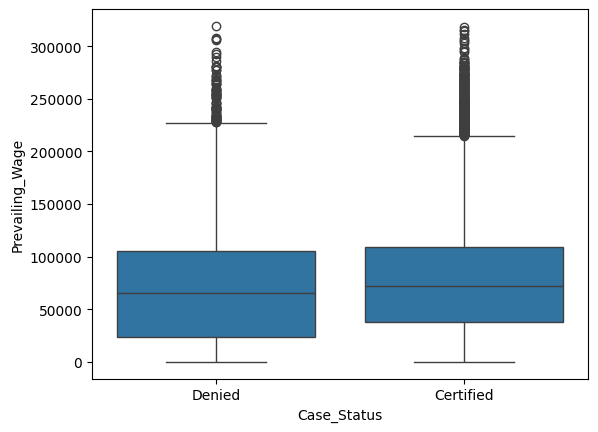

In [39]:
sns.boxplot(x='Case_Status', y='Prevailing_Wage', data=df)

<Axes: xlabel='Company_Size', ylabel='count'>

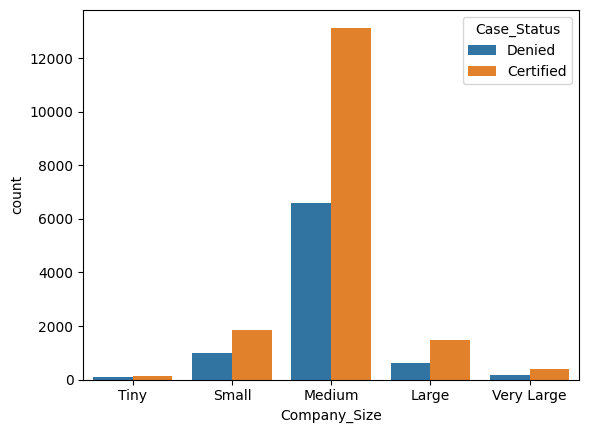

In [40]:
sns.countplot(x='Company_Size', hue='Case_Status', data=df)

<Axes: xlabel='Has_Job_Experience', ylabel='count'>

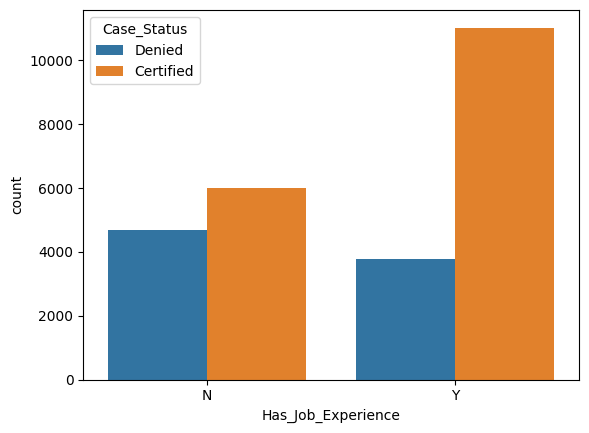

In [41]:
sns.countplot(x='Has_Job_Experience', hue='Case_Status', data=df)


<Axes: xlabel='Region_Of_Employment', ylabel='count'>

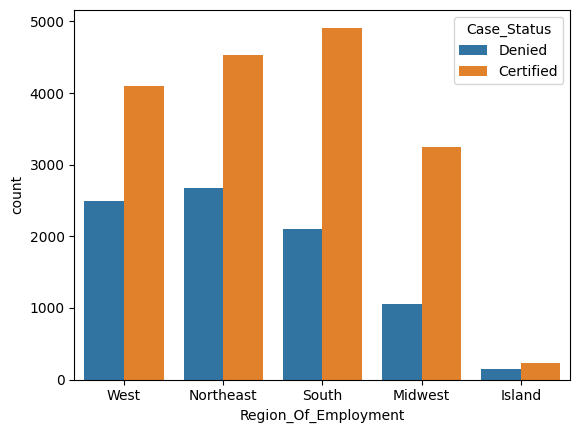

In [42]:
sns.countplot(x='Region_Of_Employment', hue='Case_Status', data=df)

In [43]:
# Example: Encode Case_Status to binary
df['Case_Status_Binary'] = df['Case_Status'].map({'Certified': 1, 'Denied': 0})

# Check correlation
print(df.corr(numeric_only=True)['Case_Status_Binary'].sort_values(ascending=False))


Case_Status_Binary    1.000000
Prevailing_Wage       0.076198
No_Of_Employees       0.008677
Yr_Of_Estab           0.008597
Name: Case_Status_Binary, dtype: float64


In [44]:
# Example: Approval rate by education
print(df.groupby('Education_Of_Employee')['Case_Status_Binary'].mean().round(2) * 100)


Education_Of_Employee
Bachelor's     62.0
Doctorate      87.0
High School    34.0
Master's       79.0
Name: Case_Status_Binary, dtype: float64


In [45]:
# Pivot table for deeper insights
pd.pivot_table(df, values='Case_Status_Binary', index='Continent', columns='Full_Time_Position', aggfunc='mean')


Full_Time_Position,N,Y
Continent,,
Africa,0.548387,0.730769
Asia,0.689851,0.648324
Europe,0.686957,0.795687
North America,0.684764,0.604925
Oceania,0.666667,0.632184
South America,0.548387,0.579781


In [46]:
print(df['Prevailing_Wage'].describe())
print(df['Yr_Of_Estab'].min(), df['Yr_Of_Estab'].max())


count     25480.000000
mean      74455.814592
std       52815.942327
min           2.140000
25%       34015.480000
50%       70308.210000
75%      107735.512500
max      319210.270000
Name: Prevailing_Wage, dtype: float64
1800 2016


In [47]:
df[['Prevailing_Wage', 'No_Of_Employees', 'Yr_Of_Estab']].corr()


,Prevailing_Wage,No_Of_Employees,Yr_Of_Estab
Prevailing_Wage,1.000000,-0.009523,0.012342
No_Of_Employees,-0.009523,1.000000,-0.017770
Yr_Of_Estab,0.012342,-0.017770,1.000000


In [48]:
df

,Case_Id,Continent,Education_Of_Employee,Has_Job_Experience,Requires_Job_Training,No_Of_Employees,Yr_Of_Estab,Region_Of_Employment,Prevailing_Wage,Unit_Of_Wage,Full_Time_Position,Case_Status,Wage_Bin,Company_Size,Case_Status_Binary
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.20,Hour,Y,Denied,Low,Large,0
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.65,Year,Y,Certified,High,Medium,1
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.86,Year,Y,Denied,Very High,Large,0
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.03,Year,Y,Denied,High,Small,0
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.39,Year,Y,Certified,Very High,Medium,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.57,Year,Y,Certified,High,Medium,1
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.79,Year,Y,Certified,Very High,Medium,1
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.85,Year,N,Certified,Very High,Medium,1
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.77,Year,Y,Certified,High,Medium,1


In [49]:
df['Case_Status'].value_counts()
df['Case_Status'].value_counts(normalize=True) * 100


,proportion
Case_Status,
Certified,66.789639
Denied,33.210361


In [50]:
df

,Case_Id,Continent,Education_Of_Employee,Has_Job_Experience,Requires_Job_Training,No_Of_Employees,Yr_Of_Estab,Region_Of_Employment,Prevailing_Wage,Unit_Of_Wage,Full_Time_Position,Case_Status,Wage_Bin,Company_Size,Case_Status_Binary
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.20,Hour,Y,Denied,Low,Large,0
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.65,Year,Y,Certified,High,Medium,1
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.86,Year,Y,Denied,Very High,Large,0
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.03,Year,Y,Denied,High,Small,0
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.39,Year,Y,Certified,Very High,Medium,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.57,Year,Y,Certified,High,Medium,1
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.79,Year,Y,Certified,Very High,Medium,1
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.85,Year,N,Certified,Very High,Medium,1
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.77,Year,Y,Certified,High,Medium,1


In [51]:
# Outlier Check
print("\nPrevailing_Wage stats:\n", df['Prevailing_Wage'].describe())
print("\n Yr_Of_Estab range:", df['Yr_Of_Estab'].min(), '-', df['Yr_Of_Estab'].max())


Prevailing_Wage stats:
 count     25480.000000
mean      74455.814592
std       52815.942327
min           2.140000
25%       34015.480000
50%       70308.210000
75%      107735.512500
max      319210.270000
Name: Prevailing_Wage, dtype: float64

 Yr_Of_Estab range: 1800 - 2016


In [52]:
# Use Credit_Status as the encoded version
print("\n\ Correlation of Case_Status with numeric vars:")
print(df[['Case_Status_Binary', 'Prevailing_Wage', 'No_Of_Employees', 'Yr_Of_Estab']].corr())




\ Correlation of Case_Status with numeric vars:
                    Case_Status_Binary  Prevailing_Wage  No_Of_Employees  \
Case_Status_Binary            1.000000         0.076198         0.008677   
Prevailing_Wage               0.076198         1.000000        -0.009523   
No_Of_Employees               0.008677        -0.009523         1.000000   
Yr_Of_Estab                   0.008597         0.012342        -0.017770   

                    Yr_Of_Estab  
Case_Status_Binary     0.008597  
Prevailing_Wage        0.012342  
No_Of_Employees       -0.017770  
Yr_Of_Estab            1.000000  


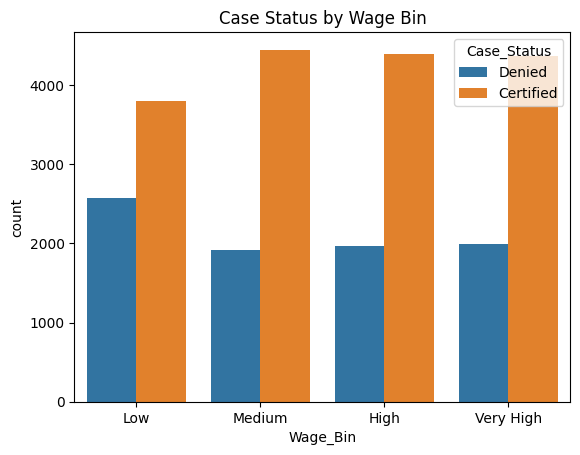

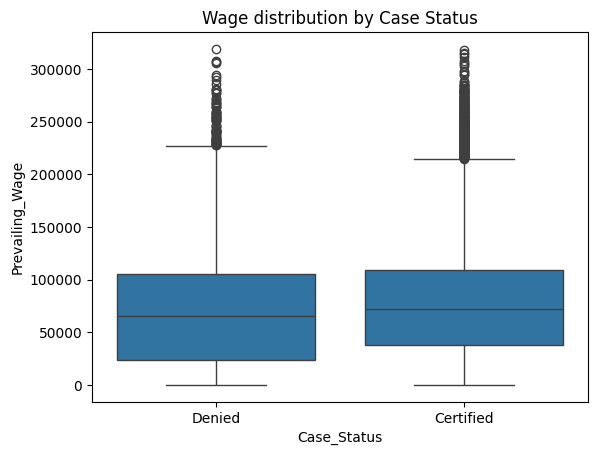

In [53]:

# Visualizations (after all figures)
sns.countplot(x='Wage_Bin', hue='Case_Status', data=df)
plt.title('Case Status by Wage Bin')
plt.show()

sns.boxplot(x='Case_Status', y='Prevailing_Wage', data=df)
plt.title('Wage distribution by Case Status')
plt.show()


In [54]:
df

,Case_Id,Continent,Education_Of_Employee,Has_Job_Experience,Requires_Job_Training,No_Of_Employees,Yr_Of_Estab,Region_Of_Employment,Prevailing_Wage,Unit_Of_Wage,Full_Time_Position,Case_Status,Wage_Bin,Company_Size,Case_Status_Binary
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.20,Hour,Y,Denied,Low,Large,0
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.65,Year,Y,Certified,High,Medium,1
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.86,Year,Y,Denied,Very High,Large,0
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.03,Year,Y,Denied,High,Small,0
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.39,Year,Y,Certified,Very High,Medium,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.57,Year,Y,Certified,High,Medium,1
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.79,Year,Y,Certified,Very High,Medium,1
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.85,Year,N,Certified,Very High,Medium,1
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.77,Year,Y,Certified,High,Medium,1


In [55]:
# Make a copy to avoid altering original DataFrame
df_prep = df.copy()

In [56]:
# 1. Frequency Encoding for Continent
continent_freq = df_prep['Continent'].value_counts(normalize=True)
df_prep['Continent_Encoded'] = df_prep['Continent'].map(continent_freq)

In [57]:
df

,Case_Id,Continent,Education_Of_Employee,Has_Job_Experience,Requires_Job_Training,No_Of_Employees,Yr_Of_Estab,Region_Of_Employment,Prevailing_Wage,Unit_Of_Wage,Full_Time_Position,Case_Status,Wage_Bin,Company_Size,Case_Status_Binary
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.20,Hour,Y,Denied,Low,Large,0
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.65,Year,Y,Certified,High,Medium,1
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.86,Year,Y,Denied,Very High,Large,0
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.03,Year,Y,Denied,High,Small,0
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.39,Year,Y,Certified,Very High,Medium,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.57,Year,Y,Certified,High,Medium,1
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.79,Year,Y,Certified,Very High,Medium,1
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.85,Year,N,Certified,Very High,Medium,1
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.77,Year,Y,Certified,High,Medium,1


In [58]:
# 2. Ordinal Encoding: Define mappings
education_map = {
    'High School': 0,
    'Bachelor\'s': 1,
    'Master\'s': 2,
    'Doctorate': 3
}
company_size_map = {
    'Small': 0,
    'Medium': 1,
    'Large': 2
}
wage_bin_map = {
    'Low': 0,
    'Medium': 1,
    'High': 2
}
unit_of_wage_map = {
    'Hour': 0,
    'Week': 1,
    'Month': 2,
    'Year': 3
}


In [59]:
df_prep['Education_Of_Employee_Encoded'] = df_prep['Education_Of_Employee'].map(education_map)
df_prep['Company_Size_Encoded'] = df_prep['Company_Size'].map(company_size_map)
df_prep['Wage_Bin_Encoded'] = df_prep['Wage_Bin'].map(wage_bin_map)
df_prep['Unit_Of_Wage_Encoded'] = df_prep['Unit_Of_Wage'].map(unit_of_wage_map)

In [60]:
# 3. Bin and Encode Yr_Of_Estab
bins = [0, 1980, 2000, 2010, 2025]
labels = [0, 1, 2, 3]
df_prep['Yr_Of_Estab_Binned'] = pd.cut(df_prep['Yr_Of_Estab'], bins=bins, labels=labels)

### 4. Label Encoding for binary yes/no fields
label_cols = ['Has_Job_Experience', 'Requires_Job_Training', 'Full_Time_Position']
le = LabelEncoder()

for col in label_cols:
    df_prep[col + '_Encoded'] = le.fit_transform(df_prep[col].astype(str))


In [61]:
#Rename Case_Status_Binary
df_prep['Case_Status_Encoded'] = df_prep['Case_Status_Binary']

In [62]:
df_prep

,Case_Id,Continent,Education_Of_Employee,Has_Job_Experience,Requires_Job_Training,No_Of_Employees,Yr_Of_Estab,Region_Of_Employment,Prevailing_Wage,Unit_Of_Wage,...,Continent_Encoded,Education_Of_Employee_Encoded,Company_Size_Encoded,Wage_Bin_Encoded,Unit_Of_Wage_Encoded,Yr_Of_Estab_Binned,Has_Job_Experience_Encoded,Requires_Job_Training_Encoded,Full_Time_Position_Encoded,Case_Status_Encoded
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.20,Hour,...,0.661735,0,2.0,0.0,0,2,0,0,1,0
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.65,Year,...,0.661735,2,1.0,2.0,3,2,1,0,1,1
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.86,Year,...,0.661735,1,2.0,NaN,3,2,0,1,1,0
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.03,Year,...,0.661735,1,0.0,2.0,3,0,0,0,1,0
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.39,Year,...,0.021625,2,1.0,NaN,3,2,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.57,Year,...,0.661735,1,1.0,2.0,3,2,1,1,1,1
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.79,Year,...,0.661735,0,1.0,NaN,3,2,1,0,1,1
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.85,Year,...,0.661735,2,1.0,NaN,3,0,1,0,0,1
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.77,Year,...,0.661735,2,1.0,2.0,3,0,1,1,1,1


In [63]:
%pip install xgboost catboost scikit-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.5 MB/s eta 0:00:00


In [64]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report

In [65]:
 # PREPROCESSING ====

df_encoded = pd.DataFrame()

# 1. Frequency Encoding - Continent
continent_freq = df['Continent'].value_counts(normalize=True)
df_encoded['Continent_Encoded'] = df['Continent'].map(continent_freq)

# 2. Ordinal Encoding
education_map = {'High School': 0, 'Bachelor\'s': 1, 'Master\'s': 2, 'Doctorate': 3}
company_size_map = {'Small': 0, 'Medium': 1, 'Large': 2}
wage_bin_map = {'Low': 0, 'Medium': 1, 'High': 2}
unit_of_wage_map = {'Hour': 0, 'Week': 1, 'Month': 2, 'Year': 3}

df_encoded['Education_Encoded'] = df['Education_Of_Employee'].map(education_map)
df_encoded['Company_Size_Encoded'] = df['Company_Size'].map(company_size_map)
df_encoded['Wage_Bin_Encoded'] = df['Wage_Bin'].map(wage_bin_map)
df_encoded['Unit_Of_Wage_Encoded'] = df['Unit_Of_Wage'].map(unit_of_wage_map)

In [66]:
# Binning Yr_Of_Estab
bins = [0, 1980, 2000, 2010, 2025]
labels = [0, 1, 2, 3]
df_encoded['Yr_Of_Estab_Binned'] = pd.cut(df['Yr_Of_Estab'], bins=bins, labels=labels).astype(int)

In [85]:
# Label Encoding for Binary Features
le = LabelEncoder()
df_encoded['Has_Job_Exp_Encoded'] = le.fit_transform(df['Has_Job_Experience'].astype(str))
df_encoded['Requires_Training_Encoded'] = le.fit_transform(df['Requires_Job_Training'].astype(str))
df_encoded['Full_Time_Encoded'] = le.fit_transform(df['Full_Time_Position'].astype(str))

In [86]:
# Target Variable
df_encoded['Case_Status_Encoded'] = df['Case_Status_Binary']

In [87]:
# MODELING

# Split Features and Target
X = df_encoded.drop('Case_Status_Encoded', axis=1)
y = df_encoded['Case_Status_Encoded']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


"""
#  Logistic Regression
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
y_pred_logreg = logreg.predict(X_test)
"""
# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

#  XGBoost
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

#  CatBoost (silent training)
cat = CatBoostClassifier(verbose=0)
cat.fit(X_train, y_train)
y_pred_cat = cat.predict(X_test)


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [15:41:59] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [70]:
# Result
models = {
 #   'Logistic Regression': y_pred_logreg,
    'Random Forest': y_pred_rf,
    'XGBoost': y_pred_xgb,
    'CatBoost': y_pred_cat
}

print("Model Performance")
for name, y_pred in models.items():
    acc = accuracy_score(y_test, y_pred)
    print(f"{name}: Accuracy = {acc:.4f}")
    print(classification_report(y_test, y_pred, zero_division=0))


=== Model Performance ===
Random Forest: Accuracy = 0.7325
              precision    recall  f1-score   support

           0       0.64      0.46      0.53      1695
           1       0.76      0.87      0.81      3401

    accuracy                           0.73      5096
   macro avg       0.70      0.66      0.67      5096
weighted avg       0.72      0.73      0.72      5096

XGBoost: Accuracy = 0.7435
              precision    recall  f1-score   support

           0       0.66      0.47      0.55      1695
           1       0.77      0.88      0.82      3401

    accuracy                           0.74      5096
   macro avg       0.72      0.67      0.68      5096
weighted avg       0.73      0.74      0.73      5096

CatBoost: Accuracy = 0.7449
              precision    recall  f1-score   support

           0       0.67      0.47      0.55      1695
           1       0.77      0.88      0.82      3401

    accuracy                           0.74      5096
   macro avg  

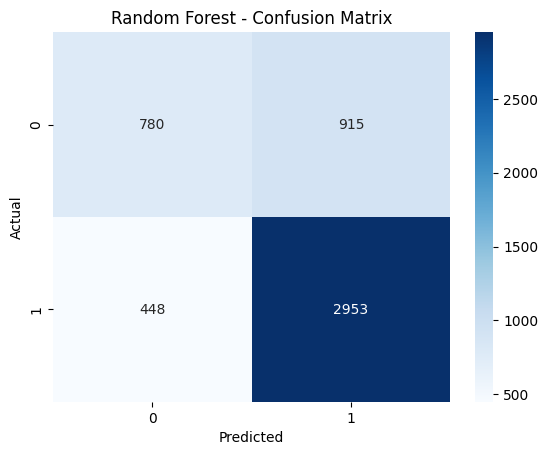

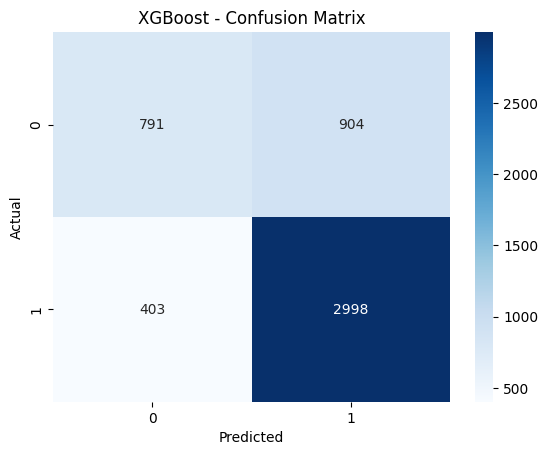

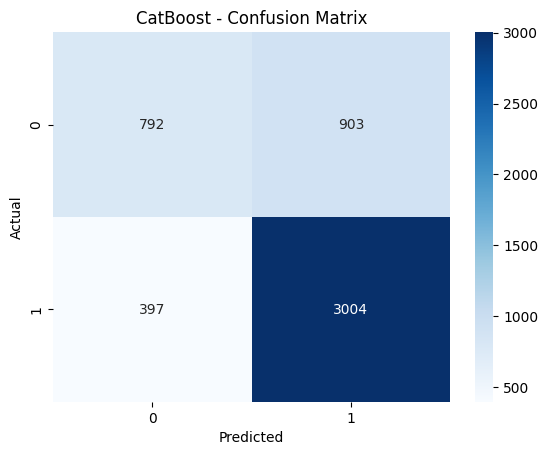

In [72]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

for name, y_pred in models.items():
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()


In [74]:
# Example training (you must have something similar)
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

import xgboost as xgb
xgb_model = xgb.XGBClassifier()
xgb_model.fit(X_train, y_train)

from catboost import CatBoostClassifier
cat_model = CatBoostClassifier(verbose=0)
cat_model.fit(X_train, y_train)



In [75]:
importances = rf_model.feature_importances_
importances = xgb_model.feature_importances_
importances = cat_model.get_feature_importance()


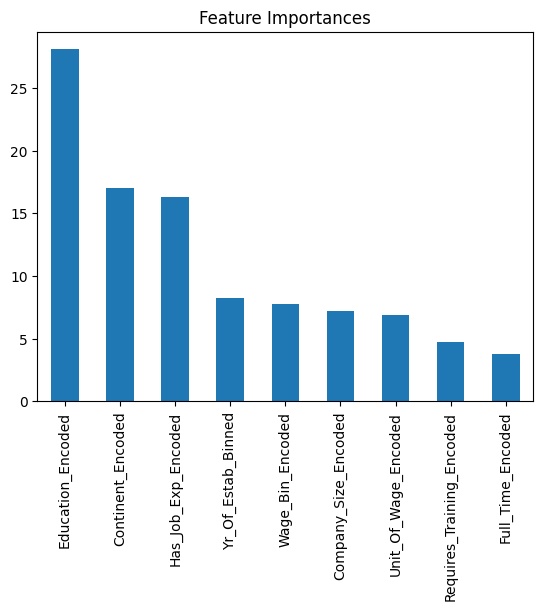

In [76]:
feature_names = X_train.columns
feature_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)
feature_imp.plot(kind='bar', title='Feature Importances')
plt.show()


In [77]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20]
}
grid_search = GridSearchCV(RandomForestClassifier(), param_grid, cv=5)
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_


In [79]:
models = {
    'Random Forest': rf_model,
    'XGBoost': xgb_model,
    'CatBoost': cat_model
}


In [80]:
from sklearn.model_selection import cross_val_score

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5)
    print(f"{name} Cross-Val Accuracy: {scores.mean():.4f}")


Random Forest Cross-Val Accuracy: 0.7080
XGBoost Cross-Val Accuracy: 0.7187
CatBoost Cross-Val Accuracy: 0.7215


Interpretation:
CatBoost performed the best (72.15%) on average across 5 folds.

It shows the strongest generalization and consistency.

Especially good if your dataset has categorical features, which CatBoost handles natively and efficiently.

XGBoost is close behind (71.87%), also a strong gradient boosting model.

Might be slightly less adaptive to categorical features unless they're properly encoded.

Random Forest (70.80%) is the weakest among the three.

Still good, but lacks the boosting advantage of the other two, especially in complex or noisy datasets.

In [89]:
from sklearn.preprocessing import LabelEncoder

# Make a copy of the data
df_encoded = df.copy()

# List of categorical features to encode
categorical_features = [
    'Continent',
    'Education_Of_Employee',
    'Company_Size',
    'Unit_Of_Wage',
    'Has_Job_Experience',
    'Requires_Job_Training',
    'Full_Time_Position'
]

# Encode each feature
le = LabelEncoder()
for col in categorical_features:
    df_encoded[col + '_Encoded'] = le.fit_transform(df_encoded[col].astype(str))

# Bin Yr_Of_Estab into categories (example: 3 bins)
df_encoded['Yr_Of_Estab_Binned'] = pd.cut(df_encoded['Yr_Of_Estab'], bins=3, labels=[0, 1, 2])


In [90]:
features = [
    'Continent_Encoded',
    'Education_Of_Employee_Encoded',
    'Company_Size_Encoded',
    'Wage_Bin',  # Already numerical
    'Unit_Of_Wage_Encoded',
    'Yr_Of_Estab_Binned',
    'Has_Job_Experience_Encoded',
    'Requires_Job_Training_Encoded',
    'Full_Time_Position_Encoded'
]

target = 'Case_Status_Binary'

X = df_encoded[features]
y = df_encoded[target]


In [92]:
print(X_train.dtypes)


Continent_Encoded                   int64
Education_Of_Employee_Encoded       int64
Company_Size_Encoded                int64
Wage_Bin                         category
Unit_Of_Wage_Encoded                int64
Yr_Of_Estab_Binned               category
Has_Job_Experience_Encoded          int64
Requires_Job_Training_Encoded       int64
Full_Time_Position_Encoded          int64
dtype: object


In [93]:
from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV

# List your categorical features (columns that are category or object dtype)
cat_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# Initialize CatBoost
cat = CatBoostClassifier(verbose=0)

# Define your parameter grid
param_grid = {
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'iterations': [100, 200]
}

# Pass the categorical features into GridSearchCV via fit_params
grid = GridSearchCV(cat, param_grid=param_grid, cv=3, scoring='accuracy', n_jobs=-1)

# Fit with categorical features specified
grid.fit(X_train, y_train, cat_features=cat_features)


GridSearchCV(cv=3,
             estimator=<catboost.core.CatBoostClassifier object at 0x7d66999ec4d0>,
             n_jobs=-1,
             param_grid={'depth': [4, 6, 8], 'iterations': [100, 200],
                         'learning_rate': [0.01, 0.05, 0.1]},
             scoring='accuracy')

In [94]:
# Results
print("Best Parameters:", grid.best_params_)
print("Best Cross-Validation Score:", grid.best_score_)

# Final model
best_cat = grid.best_estimator_
y_pred = best_cat.predict(X_test)
print("\n Classification Report:")
print(classification_report(y_test, y_pred))


Best Parameters: {'depth': 8, 'iterations': 100, 'learning_rate': 0.1}
Best Cross-Validation Score: 0.7395507109282606

 Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.46      0.55      1695
           1       0.77      0.89      0.83      3401

    accuracy                           0.75      5096
   macro avg       0.73      0.68      0.69      5096
weighted avg       0.74      0.75      0.74      5096



Interpretation of Metrics
 Class 0 (Negative class, e.g., Case_Status = Denied)
Precision 0.69: 69% of the time, when the model predicted "Denied", it was correct.

Recall 0.46: The model identified only 46% of all true "Denied" cases.

F1 0.55: Moderate performance — lower due to low recall.

 Class 1 (Positive class, e.g., Case_Status = Certified)
Precision 0.77: Good — 77% of predicted "Certified" cases were correct.

Recall 0.89: Excellent — 89% of actual certified cases were detected.
    Macro vs Weighted Averages
Macro avg (equal weight to both classes): Shows 0.73 precision, 0.68 recall, 0.69 F1 — highlights performance imbalance between classes.

Weighted avg (accounts for class imbalance): Overall model behaves similarly to the dominant class (Class 1), because it's more frequent.



F1 0.83: Strong performance — good balance between precision and recall.